In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import random
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score

warnings.filterwarnings("ignore")

In [2]:
REPO_ROOT = Path(r"/Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760")
PROJECT_ROOT_CANDIDATES = [
    Path.cwd() / "dataset",
    Path.cwd().parent / "dataset",
    Path.cwd().parent.parent / "dataset",
    REPO_ROOT / "dataset",
]

PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if path.exists()), None)
if PROJECT_ROOT is None:
    checked_paths = "\n".join(str(path) for path in PROJECT_ROOT_CANDIDATES)
    raise FileNotFoundError(f"Cannot find dataset directory. Checked:\n{checked_paths}")

os.chdir(PROJECT_ROOT)

FEATURE_A_PATH = Path("Extracted_Features/BoW_int.npy")
FEATURE_B_PATHS = [
    Path("Extracted_Features/Normalized_CH.npy"),
    Path("Extracted_Features/Normalized_CM55.npy"),
    Path("Extracted_Features/Normalized_CORR.npy"),
    Path("Extracted_Features/Normalized_EDH.npy"),
    Path("Extracted_Features/Normalized_WT.npy"),
]
TEST_FEATURE_A_PATH = Path("Extracted_Features_Test/BoW_int.npy")
TEST_FEATURE_B_PATHS = [
    Path("Extracted_Features_Test/Normalized_CH.npy"),
    Path("Extracted_Features_Test/Normalized_CM55.npy"),
    Path("Extracted_Features_Test/Normalized_CORR.npy"),
    Path("Extracted_Features_Test/Normalized_EDH.npy"),
    Path("Extracted_Features_Test/Normalized_WT.npy"),
]


In [3]:
COMMON_CONFIG = dict(
    batch_size=32,               # Number of samples sent to the model per training step.
    epochs=35,                    # Number of full passes over the training set.
    lr=1e-4,                      # Learning rate, controls the optimizer update size.
    weight_decay=1e-4,            # AdamW regularization strength to reduce overfitting.
    hidden_dims=[1024, 512, 256], # Shared MLP hidden layers used by all classifiers.
    dropout=0.3,                  # Dropout ratio applied after each hidden activation.
    activation="gelu",           # Activation function: relu / gelu / silu.
    loss="focal",
    focal_alpha=0.25,
    focal_gamma=2.0,
    threshold=0.5,                # Probability threshold for multi-label prediction.
    top_k=5,                      # Reserved for top-k evaluation/reporting consistency.
    val_ratio=0.2,                # Fraction of training data used for validation.
    random_seed=42,               # Random seed for reproducible splitting/training.
    standardize=False,            # Whether to fit StandardScaler on train features.
)

In [4]:
@dataclass
class FusionConfig:
    train_label_path: Path
    test_label_path: Path
    batch_size: int
    epochs: int
    lr: float
    weight_decay: float
    hidden_dims: list[int]
    dropout: float
    activation: str
    loss: str
    focal_alpha: float
    focal_gamma: float
    threshold: float
    top_k: int
    val_ratio: float
    random_seed: int
    standardize: bool
    embed_dim: int = 128
    lambda_nce: float = 0.1
    temperature: float = 0.1
    device: str = "mps"



config = FusionConfig(
    **COMMON_CONFIG,
    train_label_path=Path("database_labels_81_big.npy"),
    test_label_path=Path("database_labels_81_test.npy"),
)

In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        if torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if device_name == "mps" and torch.backends.mps.is_available():
        return torch.device("mps")
    if device_name == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


set_seed(config.random_seed)
DEVICE = resolve_device(config.device)

print(f"Project root: {Path.cwd()}")
print(f"Using device: {DEVICE}")


Project root: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/dataset
Using device: mps


In [6]:
class MultiModalDataset(Dataset):
    def __init__(self, xa: np.ndarray, xb: np.ndarray, y: np.ndarray):
        self.xa = torch.tensor(xa, dtype=torch.float32)
        self.xb = torch.tensor(xb, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return self.xa[idx], self.xb[idx], self.y[idx]


In [7]:
def load_array(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    return np.load(path).astype(np.float32)


In [8]:
def load_feature_group(path_or_paths: Path | list[Path]) -> np.ndarray:
    if isinstance(path_or_paths, Path):
        return load_array(path_or_paths)
    arrays = [load_array(path) for path in path_or_paths]
    return np.concatenate(arrays, axis=1)

In [9]:
def maybe_standardize(
    xa_train: np.ndarray,
    xa_val: np.ndarray,
    xa_test: np.ndarray,
    xb_train: np.ndarray,
    xb_val: np.ndarray,
    xb_test: np.ndarray,
    standardize: bool,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if not standardize:
        return xa_train, xa_val, xa_test, xb_train, xb_val, xb_test

    scaler_a = StandardScaler().fit(xa_train)
    scaler_b = StandardScaler().fit(xb_train)
    return (
        scaler_a.transform(xa_train).astype(np.float32),
        scaler_a.transform(xa_val).astype(np.float32),
        scaler_a.transform(xa_test).astype(np.float32),
        scaler_b.transform(xb_train).astype(np.float32),
        scaler_b.transform(xb_val).astype(np.float32),
        scaler_b.transform(xb_test).astype(np.float32),
    )

In [10]:
def build_dataloaders(config: FusionConfig):
    xa_all = load_feature_group(FEATURE_A_PATH)
    xb_all = load_feature_group(FEATURE_B_PATHS)
    y_all = load_array(config.train_label_path)
    xa_test = load_feature_group(TEST_FEATURE_A_PATH)
    xb_test = load_feature_group(TEST_FEATURE_B_PATHS)
    y_test = load_array(config.test_label_path)

    if len(xa_all) != len(xb_all) or len(xa_all) != len(y_all):
        raise ValueError("Train feature and label sample counts do not match.")
    if len(xa_test) != len(xb_test) or len(xa_test) != len(y_test):
        raise ValueError("Test feature and label sample counts do not match.")

    idx_train, idx_val = train_test_split(
        np.arange(len(y_all)),
        test_size=config.val_ratio,
        random_state=config.random_seed,
        shuffle=True,
    )

    xa_train, xa_val = xa_all[idx_train], xa_all[idx_val]
    xb_train, xb_val = xb_all[idx_train], xb_all[idx_val]
    y_train, y_val = y_all[idx_train], y_all[idx_val]

    xa_train, xa_val, xa_test, xb_train, xb_val, xb_test = maybe_standardize(
        xa_train, xa_val, xa_test, xb_train, xb_val, xb_test, config.standardize
    )

    train_loader = DataLoader(
        MultiModalDataset(xa_train, xb_train, y_train),
        batch_size=config.batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        MultiModalDataset(xa_val, xb_val, y_val),
        batch_size=config.batch_size,
        shuffle=False,
    )
    test_loader = DataLoader(
        MultiModalDataset(xa_test, xb_test, y_test),
        batch_size=config.batch_size,
        shuffle=False,
    )

    print("Data loading completed.")
    print(f"Feature A (BoW) dim: {xa_train.shape[1]}")
    print(f"Feature B (Color+Texture) dim: {xb_train.shape[1]}")
    print(f"Labels/classes: {y_train.shape[1]}")
    print(f"Train: {len(xa_train)}, Val: {len(xa_val)}, Test: {len(xa_test)}")

    return train_loader, val_loader, test_loader, xa_train.shape[1], xb_train.shape[1], y_train.shape[1]

train_loader, val_loader, test_loader, DIM_A, DIM_B, NUM_CLASSES = build_dataloaders(config)



Data loading completed.
Feature A (BoW) dim: 500
Feature B (Color+Texture) dim: 634
Labels/classes: 81
Train: 154987, Val: 38747, Test: 2100


In [11]:
def make_activation(name: str) -> nn.Module:
    activations = {
        "relu": nn.ReLU,
        "gelu": nn.GELU,
        "silu": nn.SiLU,
    }
    if name not in activations:
        raise ValueError(f"Unsupported activation: {name}")
    return activations[name]()


In [12]:
def make_mlp(
    input_dim: int,
    hidden_dims: list[int],
    output_dim: int,
    dropout: float,
    activation: str,
) -> nn.Sequential:
    layers: list[nn.Module] = []
    prev_dim = input_dim
    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, hidden_dim))
        layers.append(make_activation(activation))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev_dim = hidden_dim
    layers.append(nn.Linear(prev_dim, output_dim))
    return nn.Sequential(*layers)


In [13]:
def info_nce_loss(h1: torch.Tensor, h2: torch.Tensor, temperature: float = 0.1) -> torch.Tensor:
    h1 = F.normalize(h1, dim=-1)
    h2 = F.normalize(h2, dim=-1)
    logits = torch.matmul(h1, h2.T) / temperature
    labels = torch.arange(h1.size(0), device=h1.device)
    loss_12 = F.cross_entropy(logits, labels)
    loss_21 = F.cross_entropy(logits.T, labels)
    return (loss_12 + loss_21) / 2.0

In [14]:
class BaselineModel(nn.Module):
    def __init__(self, input_dim: int, feature_type: str, config: FusionConfig):
        super().__init__()
        self.feature_type = feature_type
        self.net = make_mlp(
            input_dim=input_dim,
            hidden_dims=config.hidden_dims,
            output_dim=NUM_CLASSES,
            dropout=config.dropout,
            activation=config.activation,
        )

    def forward(self, xa: torch.Tensor, xb: torch.Tensor):
        x = xa if self.feature_type == "A" else xb
        return self.net(x), None, None


In [15]:
class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = targets * probs + (1 - targets) * (1 - probs)
        focal_weight = (1 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * bce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

In [16]:
class EarlyFusion(nn.Module):
    def __init__(self, config: FusionConfig):
        super().__init__()
        self.proj_A = nn.Sequential(nn.Linear(DIM_A, config.embed_dim), make_activation(config.activation))
        self.proj_B = nn.Sequential(nn.Linear(DIM_B, config.embed_dim), make_activation(config.activation))
        self.classifier = make_mlp(
            input_dim=config.embed_dim * 2,
            hidden_dims=config.hidden_dims,
            output_dim=NUM_CLASSES,
            dropout=config.dropout,
            activation=config.activation,
        )

    def forward(self, xa: torch.Tensor, xb: torch.Tensor):
        h1 = self.proj_A(xa)
        h2 = self.proj_B(xb)
        fused = torch.cat([h1, h2], dim=1)
        return self.classifier(fused), h1, h2

In [17]:
class GatedFusion(nn.Module):
    def __init__(self, config: FusionConfig):
        super().__init__()
        self.proj_A = nn.Sequential(nn.Linear(DIM_A, config.embed_dim), make_activation(config.activation))
        self.proj_B = nn.Sequential(nn.Linear(DIM_B, config.embed_dim), make_activation(config.activation))
        self.gate_layer = nn.Linear(config.embed_dim * 2, config.embed_dim)
        self.classifier = make_mlp(
            input_dim=config.embed_dim,
            hidden_dims=config.hidden_dims,
            output_dim=NUM_CLASSES,
            dropout=config.dropout,
            activation=config.activation,
        )

    def forward(self, xa: torch.Tensor, xb: torch.Tensor):
        h1 = self.proj_A(xa)
        h2 = self.proj_B(xb)
        gate = torch.sigmoid(self.gate_layer(torch.cat([h1, h2], dim=-1)))
        fused = gate * h1 + (1.0 - gate) * h2
        return self.classifier(fused), h1, h2


In [18]:
def evaluate(model: nn.Module, loader: DataLoader, threshold: float = 0.5) -> tuple[float, float, float]:
    model.eval()
    all_targets, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for xa, xb, y in loader:
            xa = xa.to(DEVICE)
            xb = xb.to(DEVICE)
            y = y.to(DEVICE)
            logits, _, _ = model(xa, xb)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
            all_preds.append((probs > threshold).float().cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    mi_f1 = f1_score(all_targets, all_preds, average="micro", zero_division=0)
    ma_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    try:
        map_score = average_precision_score(all_targets, all_probs, average="macro")
    except ValueError:
        map_score = 0.0
    return map_score, mi_f1, ma_f1

In [19]:
def build_criterion(config: FusionConfig) -> nn.Module:
    if config.loss == "bce":
        return nn.BCEWithLogitsLoss()
    if config.loss == "focal":
        return FocalLossWithLogits(
            alpha=config.focal_alpha,
            gamma=config.focal_gamma,
        )
    raise ValueError(f"Unsupported loss for this fusion baseline: {config.loss}")


In [20]:
def train_model(model_name: str, model: nn.Module, config: FusionConfig, use_infonce: bool = False):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    criterion = build_criterion(config)

    print(f"\n{'=' * 50}\nTraining: {model_name}\n{'=' * 50}")
    print(f"MLP hidden_dims={config.hidden_dims}, activation={config.activation}, dropout={config.dropout}")

    for epoch in range(config.epochs):
        model.train()
        epoch_loss = 0.0
        for xa, xb, y in train_loader:
            xa = xa.to(DEVICE)
            xb = xb.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            logits, h1, h2 = model(xa, xb)
            loss = criterion(logits, y)

            if use_infonce and h1 is not None and h2 is not None:
                loss = loss + config.lambda_nce * info_nce_loss(h1, h2, config.temperature)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        val_map, val_mi, val_ma = evaluate(model, val_loader, threshold=config.threshold)
        print(
            f"Epoch [{epoch + 1:02d}/{config.epochs}] "
            f"Loss: {epoch_loss / max(len(train_loader), 1):.4f} | "
            f"Val mAP: {val_map:.4f} | Mi-F1: {val_mi:.4f} | Ma-F1: {val_ma:.4f}"
        )

    test_map, test_mi, test_ma = evaluate(model, test_loader, threshold=config.threshold)
    print(f"[TEST SET] mAP: {test_map:.4f} | Micro-F1: {test_mi:.4f} | Macro-F1: {test_ma:.4f}")
    return {"mAP": test_map, "Mi_F1": test_mi, "Ma_F1": test_ma, "model": model}


In [21]:
results = {}

results["Baseline_A (BoW)"] = train_model(
    "Baseline (Local: BoW)",
    BaselineModel(DIM_A, "A", config),
    config,
)

results["Baseline_B (Color+Tex)"] = train_model(
    "Baseline (Global: Color+Texture)",
    BaselineModel(DIM_B, "B", config),
    config,
)

results["Early_Fusion (Concat)"] = train_model(
    "Early Fusion (Concat)",
    EarlyFusion(config),
    config,
)

results["Gated_Fusion + InfoNCE"] = train_model(
    "Gated Fusion + InfoNCE",
    GatedFusion(config),
    config,
    use_infonce=True,
)

results["Gated_Fusion (No NCE)"] = train_model(
    "Gated Fusion (No InfoNCE)",
    GatedFusion(config),
    config,
    use_infonce=False,
)

print("\n" + "=" * 68)
print(f"{'Experiment Model':<30} | {'mAP (%)':<8} | {'Micro-F1':<8} | {'Macro-F1':<8}")
print("-" * 68)
for name, res in results.items():
    print(f"{name:<30} | {res['mAP'] * 100:.2f}     | {res['Mi_F1'] * 100:.2f}     | {res['Ma_F1'] * 100:.2f}")
print("=" * 68)



Training: Baseline (Local: BoW)
MLP hidden_dims=[1024, 512, 256], activation=gelu, dropout=0.3
Epoch [01/35] Loss: 0.0097 | Val mAP: 0.1149 | Mi-F1: 0.1629 | Ma-F1: 0.0136
Epoch [02/35] Loss: 0.0084 | Val mAP: 0.1316 | Mi-F1: 0.1963 | Ma-F1: 0.0195
Epoch [03/35] Loss: 0.0080 | Val mAP: 0.1389 | Mi-F1: 0.1829 | Ma-F1: 0.0212
Epoch [04/35] Loss: 0.0078 | Val mAP: 0.1443 | Mi-F1: 0.2213 | Ma-F1: 0.0269
Epoch [05/35] Loss: 0.0077 | Val mAP: 0.1481 | Mi-F1: 0.2325 | Ma-F1: 0.0311
Epoch [06/35] Loss: 0.0077 | Val mAP: 0.1497 | Mi-F1: 0.2362 | Ma-F1: 0.0336
Epoch [07/35] Loss: 0.0075 | Val mAP: 0.1525 | Mi-F1: 0.2420 | Ma-F1: 0.0345
Epoch [08/35] Loss: 0.0074 | Val mAP: 0.1495 | Mi-F1: 0.2394 | Ma-F1: 0.0349
Epoch [09/35] Loss: 0.0073 | Val mAP: 0.1531 | Mi-F1: 0.2638 | Ma-F1: 0.0371
Epoch [10/35] Loss: 0.0073 | Val mAP: 0.1523 | Mi-F1: 0.2782 | Ma-F1: 0.0427
Epoch [11/35] Loss: 0.0071 | Val mAP: 0.1532 | Mi-F1: 0.2773 | Ma-F1: 0.0426
Epoch [12/35] Loss: 0.0071 | Val mAP: 0.1520 | Mi-F1: 0.2


🔍 Visualizing the feature space of [Gated Fusion + InfoNCE]...
⏳ Running t-SNE dimensionality reduction, please wait...


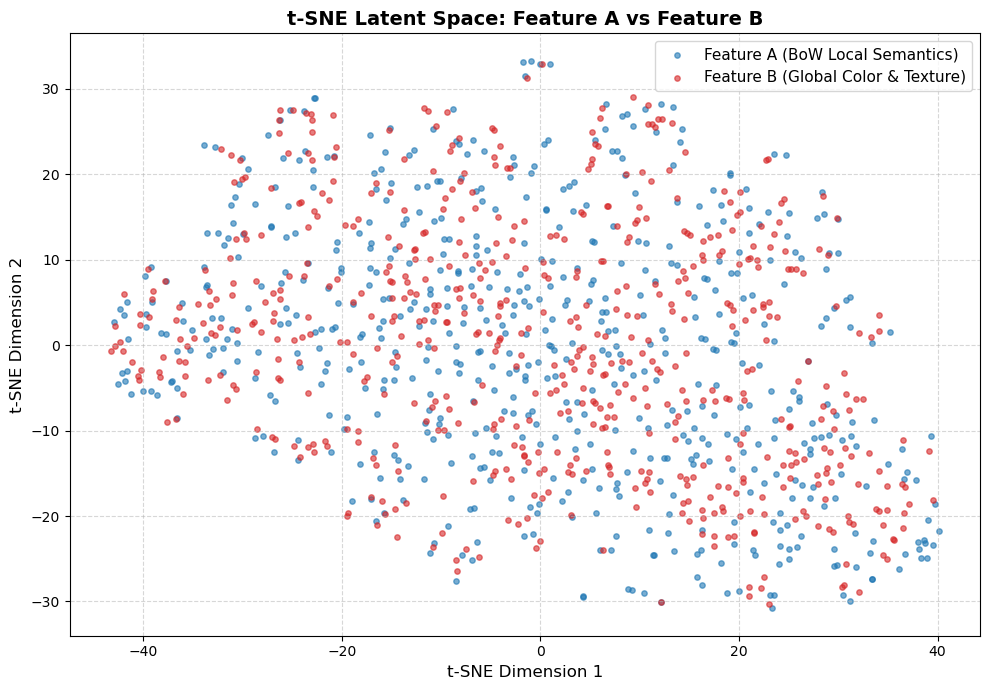

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_embeddings(model, dataloader, num_samples=500):
    """
   Visualize the distribution of Feature A (BoW) and Feature B (Color+Texture) projected into the latent space.
   This is used to explore whether forced alignment destroys the uniqueness of heterogeneous features.
    """
    model.eval()
    model.to(DEVICE)
    h1_list, h2_list = [], []

    with torch.no_grad():
        for i, (xa, xb, _) in enumerate(dataloader):
            xa, xb = xa.to(DEVICE), xb.to(DEVICE)
            # Get the hidden layer output (h1, h2) of the model
            _, h1, h2 = model(xa, xb)

            if h1 is not None and h2 is not None:
                h1_list.append(h1.cpu().numpy())
                h2_list.append(h2.cpu().numpy())

            # Stop once a sufficient number of samples have been collected.
            if sum([len(h) for h in h1_list]) >= num_samples:
                break

    if not h1_list:
        print("❌ The model has no multimodal hidden layer outputs (h1, h2), visualization is not possible.")
        return

    # Extract a specified number of samples
    h1_arr = np.vstack(h1_list)[:num_samples]
    h2_arr = np.vstack(h2_list)[:num_samples]

    # Perform T-SNE dimensionality reduction by stacking two features together
    combined = np.vstack([h1_arr, h2_arr])
    # 0 represents Feature A (BoW), 1 represents Feature B (Color + Texture)
    labels = np.array([0]*num_samples + [1]*num_samples)

    print("⏳ Running t-SNE dimensionality reduction, please wait...")
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(combined)

    # Start drawing
    plt.figure(figsize=(10, 7))
    plt.scatter(reduced[labels==0, 0], reduced[labels==0, 1],
                alpha=0.6, label="Feature A (BoW Local Semantics)", c='#1f77b4', s=15)
    plt.scatter(reduced[labels==1, 0], reduced[labels==1, 1],
                alpha=0.6, label="Feature B (Global Color & Texture)", c='#d62728', s=15)

    plt.title("t-SNE Latent Space: Feature A vs Feature B", fontsize=14, fontweight='bold')
    plt.xlabel("t-SNE Dimension 1", fontsize=12)
    plt.ylabel("t-SNE Dimension 2", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# ==========================================
# Visualization: Observe the feature distribution after adding InfoNCE.
# ==========================================
print("\n🔍 Visualizing the feature space of [Gated Fusion + InfoNCE]...")
# Note that the dictionary key names here must be exactly the same as the names of the results you get in Cell 5!
if 'Gated_Fusion + InfoNCE' in results:
    visualize_embeddings(results['Gated_Fusion + InfoNCE']['model'], test_loader, num_samples=600)
else:
    print("The model cannot be found. Please check if the model has been trained and saved in the results dictionary in Cell 5.")


===== Baseline_A (BoW) =====


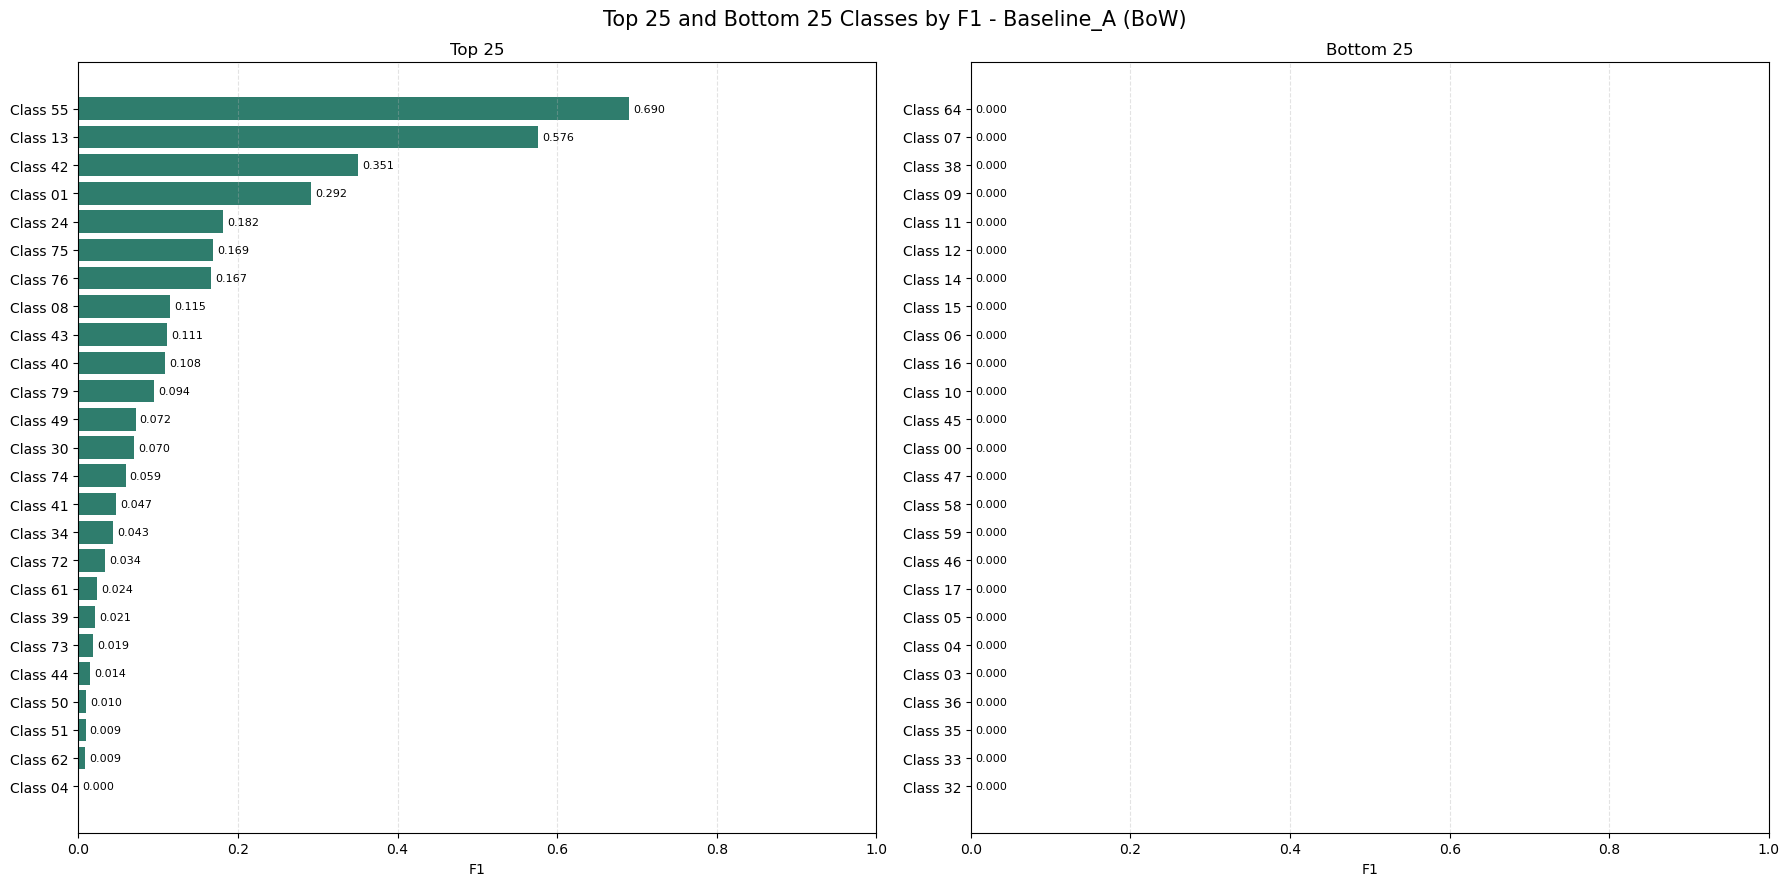

Saved CSV: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Baseline_A_BoW_per_class_metrics.csv
Saved plot: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Baseline_A_BoW_top25_bottom25_f1.png
Top 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
0,55,Class 55,1162,0.854061,0.579174,0.690256,0.843855
1,13,Class 13,924,0.807018,0.448052,0.576200,0.779894
2,42,Class 42,244,0.440994,0.290984,0.350617,0.336058
3,1,Class 01,207,0.488636,0.207729,0.291525,0.305161
4,24,Class 24,140,1.000000,0.100000,0.181818,0.446454
5,75,Class 75,734,0.615385,0.098093,0.169213,0.547427
6,76,Class 76,11,1.000000,0.090909,0.166667,0.254801
7,8,Class 08,272,0.739130,0.062500,0.115254,0.421825
8,43,Class 43,16,0.500000,0.062500,0.111111,0.293225
9,40,Class 40,33,0.500000,0.060606,0.108108,0.104609


Bottom 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
56,38,Class 38,11,0.0,0.0,0.0,0.047778
78,36,Class 36,0,0.0,0.0,0.0,NaN
77,35,Class 35,11,0.0,0.0,0.0,0.057706
76,33,Class 33,65,0.0,0.0,0.0,0.071998
75,32,Class 32,13,0.0,0.0,0.0,0.006971
74,31,Class 31,7,0.0,0.0,0.0,0.008331
73,29,Class 29,14,0.0,0.0,0.0,0.049263
72,28,Class 28,46,0.0,0.0,0.0,0.109196
71,27,Class 27,24,0.0,0.0,0.0,0.055238
70,26,Class 26,5,0.0,0.0,0.0,0.023573



===== Baseline_B (Color+Tex) =====


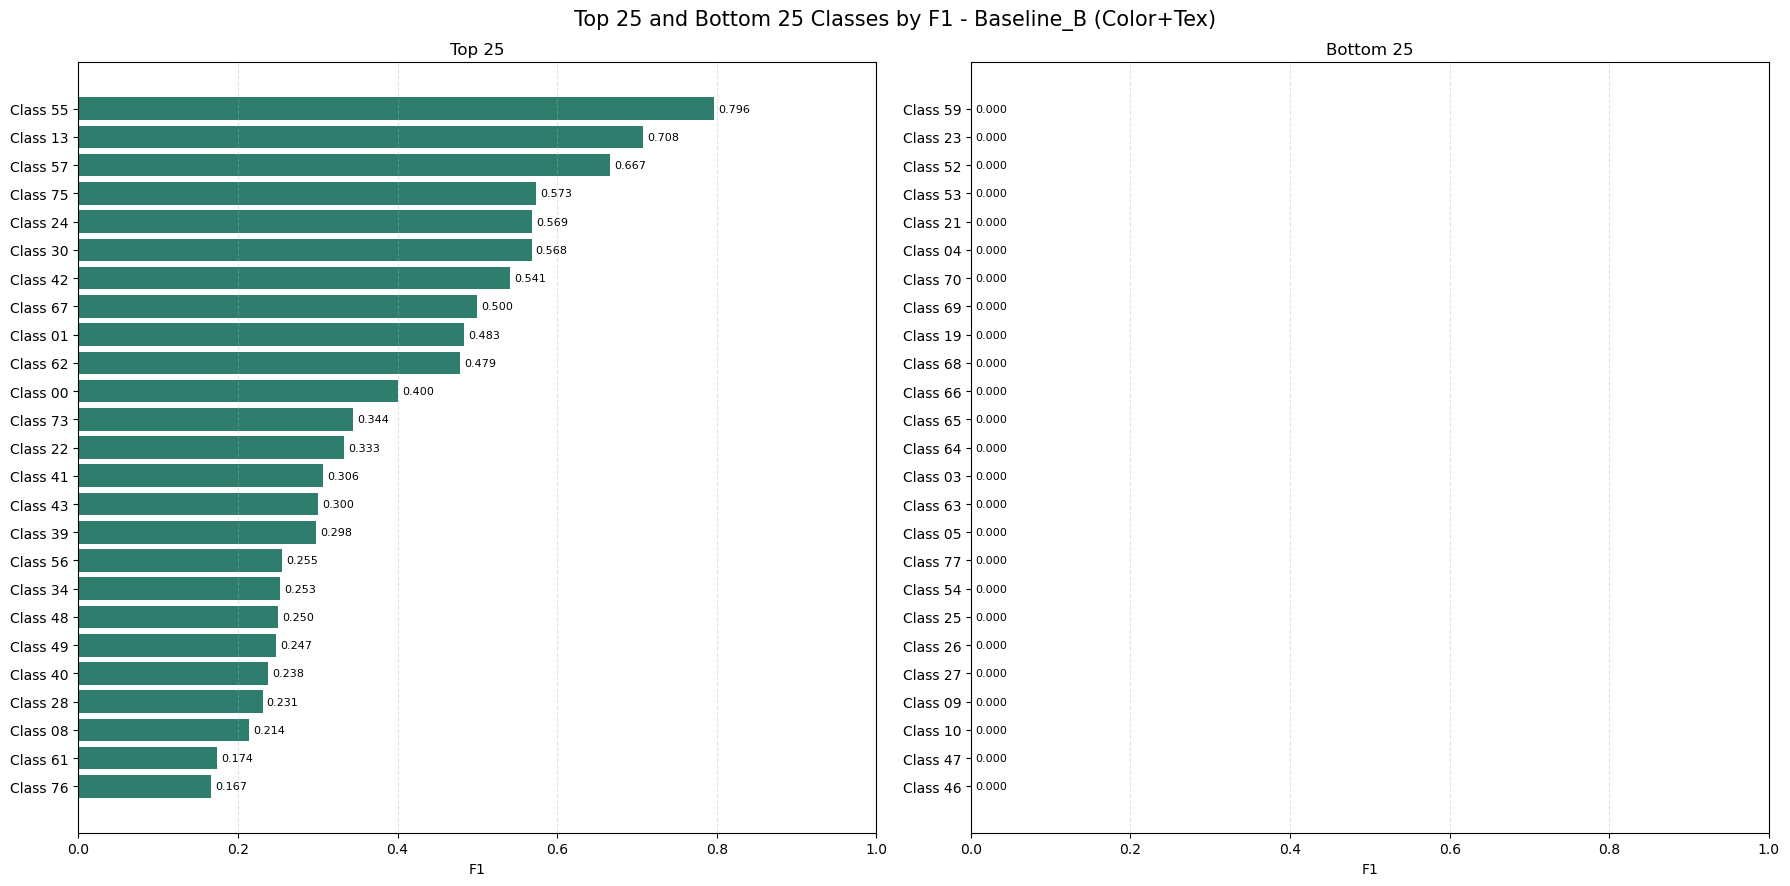

Saved CSV: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Baseline_B_Color_Tex_per_class_metrics.csv
Saved plot: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Baseline_B_Color_Tex_top25_bottom25_f1.png
Top 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
0,55,Class 55,1162,0.918919,0.702238,0.796098,0.924772
1,13,Class 13,924,0.897010,0.584416,0.707733,0.887973
2,57,Class 57,2,1.000000,0.500000,0.666667,0.600000
3,75,Class 75,734,0.890805,0.422343,0.573013,0.830760
4,24,Class 24,140,0.906250,0.414286,0.568627,0.797027
5,30,Class 30,324,0.877419,0.419753,0.567850,0.772831
6,42,Class 42,244,0.766917,0.418033,0.541114,0.639673
7,67,Class 67,3,1.000000,0.333333,0.500000,0.362080
8,1,Class 01,207,0.791209,0.347826,0.483221,0.621288
9,62,Class 62,230,0.973333,0.317391,0.478689,0.846851


Bottom 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
56,52,Class 52,4,0.0,0.0,0.0,0.029326
78,9,Class 09,28,0.0,0.0,0.0,0.224317
77,10,Class 10,6,0.0,0.0,0.0,0.050252
76,47,Class 47,3,0.0,0.0,0.0,0.064026
75,46,Class 46,1,0.0,0.0,0.0,0.100000
74,45,Class 45,7,0.0,0.0,0.0,0.344714
73,11,Class 11,7,0.0,0.0,0.0,0.038497
72,14,Class 14,1,0.0,0.0,0.0,0.017857
71,16,Class 16,8,0.0,0.0,0.0,0.063484
70,38,Class 38,11,0.0,0.0,0.0,0.082865



===== Early_Fusion (Concat) =====


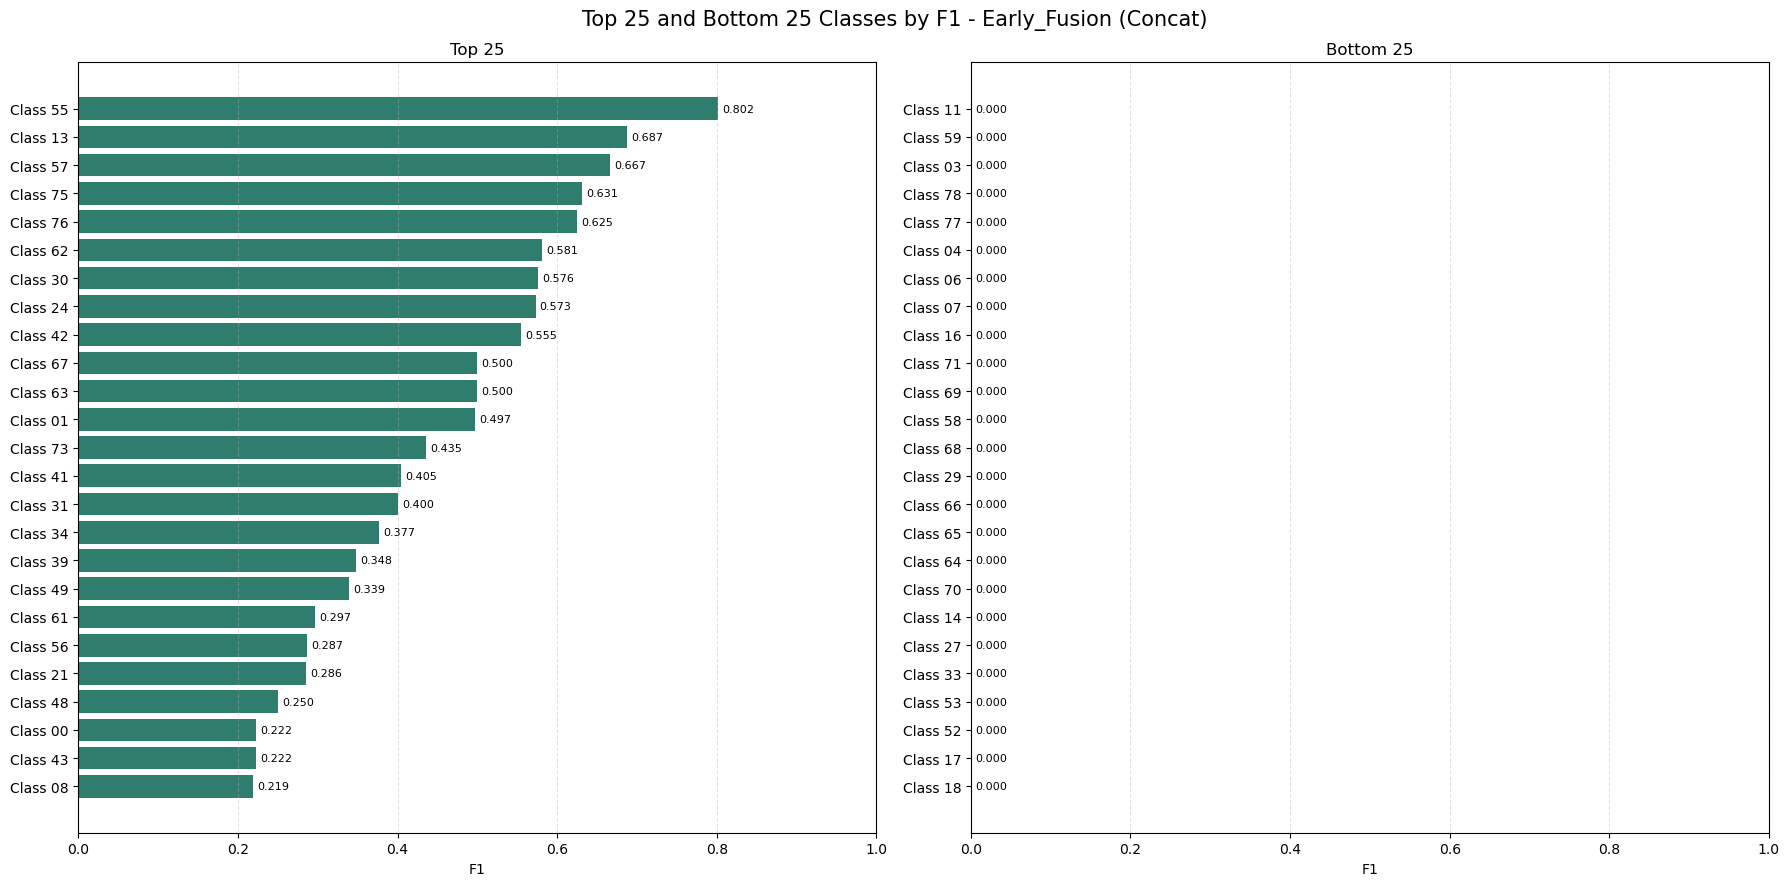

Saved CSV: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Early_Fusion_Concat_per_class_metrics.csv
Saved plot: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Early_Fusion_Concat_top25_bottom25_f1.png
Top 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
0,55,Class 55,1162,0.899358,0.722892,0.801527,0.914298
1,13,Class 13,924,0.882852,0.562771,0.687376,0.875002
2,57,Class 57,2,1.000000,0.500000,0.666667,0.529412
3,75,Class 75,734,0.851852,0.501362,0.631218,0.805047
4,76,Class 76,11,1.000000,0.454545,0.625000,0.762489
5,62,Class 62,230,0.932692,0.421739,0.580838,0.827361
6,30,Class 30,324,0.849398,0.435185,0.575510,0.751174
7,24,Class 24,140,0.966102,0.407143,0.572864,0.784634
8,42,Class 42,244,0.711538,0.454918,0.555000,0.599303
9,67,Class 67,3,1.000000,0.333333,0.500000,0.340900


Bottom 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
56,3,Class 03,4,0.0,0.0,0.0,0.422619
78,53,Class 53,26,0.0,0.0,0.0,0.139849
77,52,Class 52,4,0.0,0.0,0.0,0.010502
76,17,Class 17,2,0.0,0.0,0.0,0.054887
75,18,Class 18,13,0.0,0.0,0.0,0.162854
74,47,Class 47,3,0.0,0.0,0.0,0.168215
73,46,Class 46,1,0.0,0.0,0.0,0.500000
72,45,Class 45,7,0.0,0.0,0.0,0.211190
71,19,Class 19,0,0.0,0.0,0.0,NaN
70,20,Class 20,4,0.0,0.0,0.0,0.171795



===== Gated_Fusion + InfoNCE =====


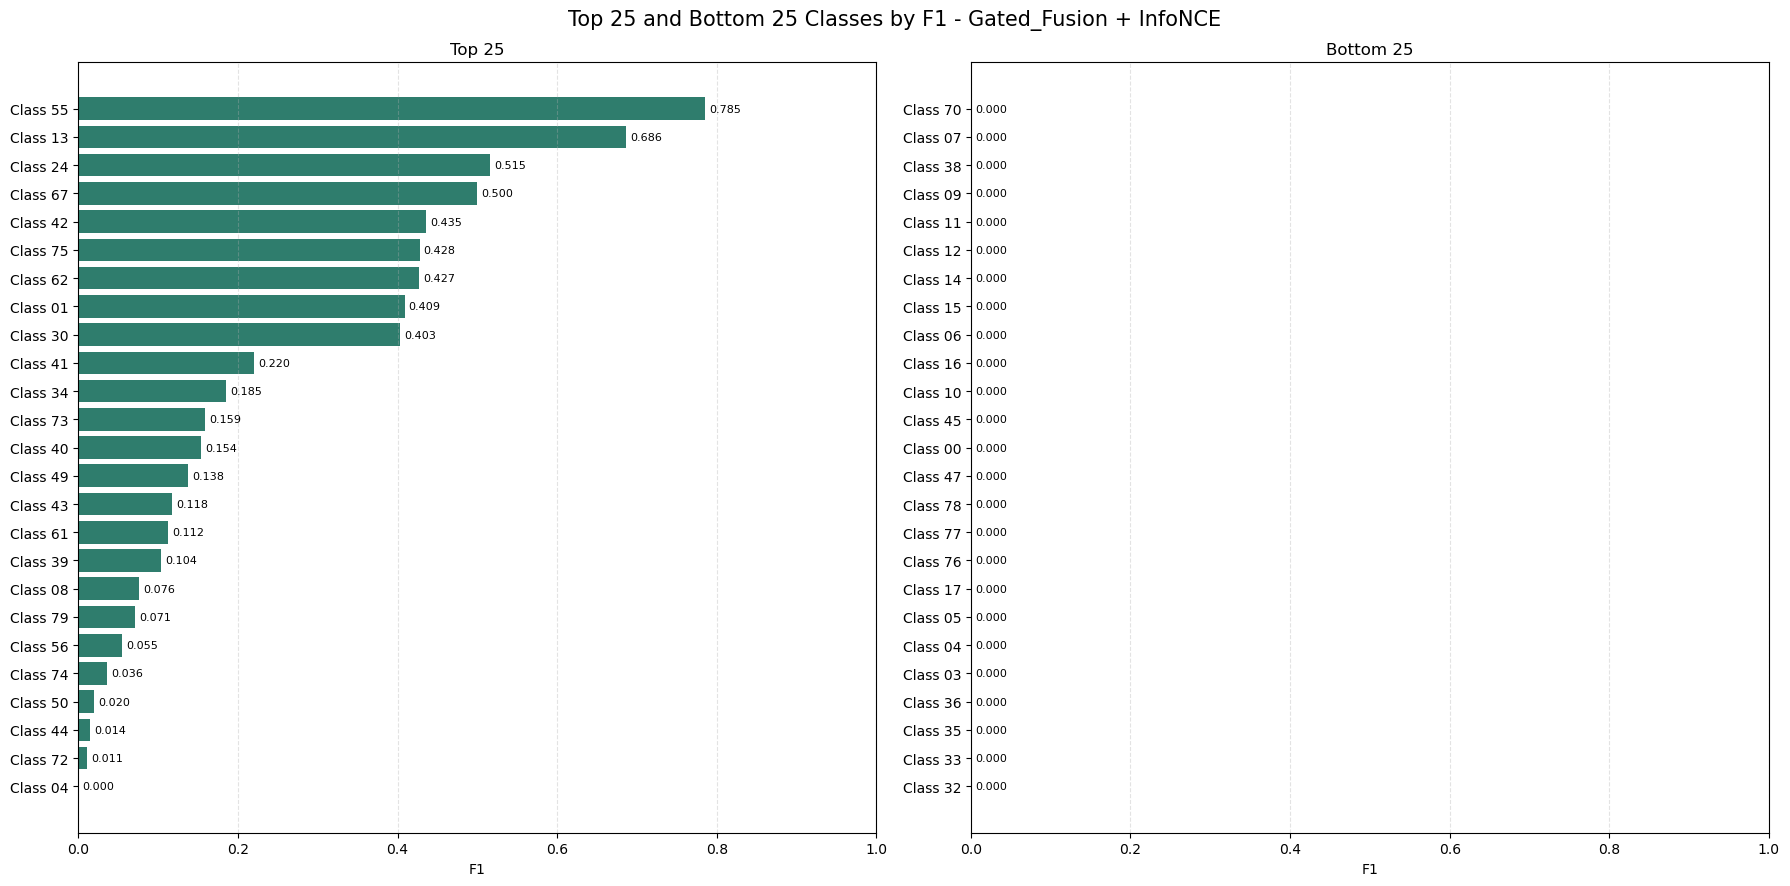

Saved CSV: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Gated_Fusion_InfoNCE_per_class_metrics.csv
Saved plot: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Gated_Fusion_InfoNCE_top25_bottom25_f1.png
Top 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
0,55,Class 55,1162,0.926230,0.680723,0.784722,0.921090
1,13,Class 13,924,0.908929,0.550866,0.685984,0.886767
2,24,Class 24,140,0.925926,0.357143,0.515464,0.773651
3,67,Class 67,3,1.000000,0.333333,0.500000,0.341527
4,42,Class 42,244,0.770833,0.303279,0.435294,0.601098
5,75,Class 75,734,0.911111,0.279292,0.427529,0.791851
6,62,Class 62,230,0.969231,0.273913,0.427119,0.781935
7,1,Class 01,207,0.835821,0.270531,0.408759,0.584292
8,30,Class 30,324,0.903226,0.259259,0.402878,0.729755
9,41,Class 41,324,0.854167,0.126543,0.220430,0.651106


Bottom 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
56,38,Class 38,11,0.0,0.0,0.0,0.112583
78,36,Class 36,0,0.0,0.0,0.0,NaN
77,35,Class 35,11,0.0,0.0,0.0,0.199329
76,33,Class 33,65,0.0,0.0,0.0,0.262751
75,32,Class 32,13,0.0,0.0,0.0,0.190825
74,31,Class 31,7,0.0,0.0,0.0,0.502182
73,29,Class 29,14,0.0,0.0,0.0,0.201223
72,28,Class 28,46,0.0,0.0,0.0,0.382635
71,27,Class 27,24,0.0,0.0,0.0,0.286039
70,26,Class 26,5,0.0,0.0,0.0,0.163073



===== Gated_Fusion (No NCE) =====


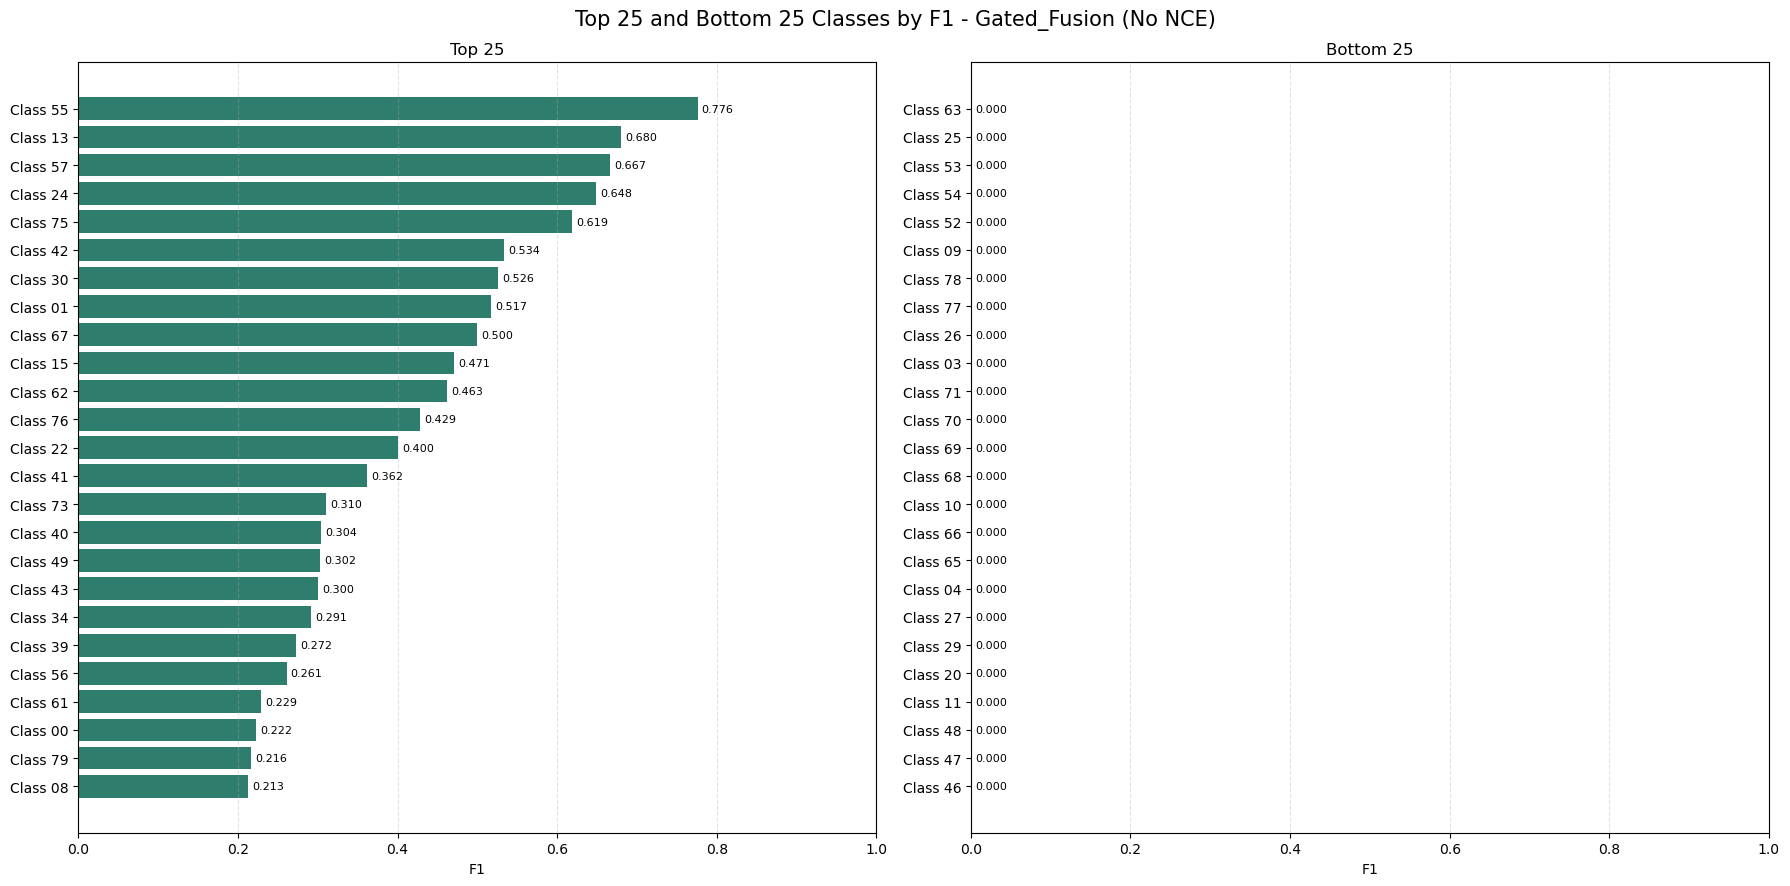

Saved CSV: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Gated_Fusion_No_NCE_per_class_metrics.csv
Saved plot: /Users/wangjue/⭐️StudyInUoA/Stage 7/COMPSCI 760-Advanced Topics in Machine Learning/760-project/760/81/E4/per_class_plots/Gated_Fusion_No_NCE_top25_bottom25_f1.png
Top 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
0,55,Class 55,1162,0.915691,0.672978,0.775794,0.912191
1,13,Class 13,924,0.889667,0.549784,0.679599,0.876746
2,57,Class 57,2,1.000000,0.500000,0.666667,0.507246
3,24,Class 24,140,0.921053,0.500000,0.648148,0.810887
4,75,Class 75,734,0.853717,0.485014,0.618593,0.803969
5,42,Class 42,244,0.681529,0.438525,0.533666,0.566276
6,30,Class 30,324,0.889706,0.373457,0.526087,0.760479
7,1,Class 01,207,0.745455,0.396135,0.517350,0.586363
8,67,Class 67,3,1.000000,0.333333,0.500000,0.501160
9,15,Class 15,13,1.000000,0.307692,0.470588,0.515786


Bottom 25 classes:


,class_id,class_name,support,precision,recall,f1,average_precision
56,53,Class 53,26,0.0,0.0,0.0,0.118971
78,11,Class 11,7,0.0,0.0,0.0,0.042582
77,48,Class 48,7,0.0,0.0,0.0,0.229911
76,47,Class 47,3,0.0,0.0,0.0,0.174377
75,46,Class 46,1,0.0,0.0,0.0,0.500000
74,45,Class 45,7,0.0,0.0,0.0,0.281109
73,14,Class 14,1,0.0,0.0,0.0,0.047619
72,16,Class 16,8,0.0,0.0,0.0,0.104471
71,17,Class 17,2,0.0,0.0,0.0,0.571429
70,18,Class 18,13,0.0,0.0,0.0,0.098988


In [23]:
# Per-class classification effect for every model: Top 25 and Bottom 25 classes
# Run this cell after the training cell has finished and `results` is available.

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import average_precision_score, precision_recall_fscore_support

OUTPUT_DIR = PROJECT_ROOT.parent / "81" / "E4" / "per_class_plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TOP_K = 25
THRESHOLD = config.threshold

# If you have real label names, define `label_names` before running this cell.
# Otherwise the code will use Class 00, Class 01, ...
if "label_names" in globals() and len(label_names) == NUM_CLASSES:
    CLASS_NAMES = list(label_names)
elif "class_names" in globals() and len(class_names) == NUM_CLASSES:
    CLASS_NAMES = list(class_names)
else:
    CLASS_NAMES = [f"Class {i:02d}" for i in range(NUM_CLASSES)]


def safe_filename(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_")


def collect_model_predictions(model, loader, threshold=0.5):
    model.eval()
    model.to(DEVICE)
    all_targets, all_probs, all_preds = [], [], []

    with torch.no_grad():
        for xa, xb, y in loader:
            xa = xa.to(DEVICE)
            xb = xb.to(DEVICE)
            logits, _, _ = model(xa, xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(np.float32)

            all_probs.append(probs)
            all_preds.append(preds)
            all_targets.append(y.cpu().numpy())

    return np.vstack(all_targets), np.vstack(all_probs), np.vstack(all_preds)


def build_per_class_metrics(y_true, y_prob, y_pred, class_names):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        zero_division=0,
    )

    average_precision = []
    for class_idx in range(y_true.shape[1]):
        if len(np.unique(y_true[:, class_idx])) < 2:
            average_precision.append(np.nan)
        else:
            average_precision.append(
                average_precision_score(y_true[:, class_idx], y_prob[:, class_idx])
            )

    df = pd.DataFrame(
        {
            "class_id": np.arange(y_true.shape[1]),
            "class_name": class_names,
            "support": support.astype(int),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "average_precision": average_precision,
        }
    )
    return df.sort_values("f1", ascending=False).reset_index(drop=True)


def plot_top_bottom_classes(metrics_df, model_name, top_k=25, metric="f1"):
    top_df = metrics_df.sort_values(metric, ascending=False).head(top_k)
    bottom_df = metrics_df.sort_values(metric, ascending=True).head(top_k)

    fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True)
    fig.suptitle(f"Top {top_k} and Bottom {top_k} Classes by {metric.upper()} - {model_name}", fontsize=15)

    for ax, df_part, title, color in [
        (axes[0], top_df.iloc[::-1], f"Top {top_k}", "#2f7d6d"),
        (axes[1], bottom_df.iloc[::-1], f"Bottom {top_k}", "#b65b4b"),
    ]:
        bars = ax.barh(df_part["class_name"], df_part[metric], color=color)
        ax.bar_label(bars, labels=[f"{v:.3f}" for v in df_part[metric]], padding=3, fontsize=8)
        ax.set_title(title)
        ax.set_xlabel(metric.upper())
        ax.grid(axis="x", linestyle="--", alpha=0.35)

    max_value = float(metrics_df[metric].max()) if len(metrics_df) else 1.0
    axes[0].set_xlim(0, max(1.0, max_value * 1.12))
    axes[1].set_xlim(0, max(1.0, max_value * 1.12))
    plt.tight_layout()

    plot_path = OUTPUT_DIR / f"{safe_filename(model_name)}_top{top_k}_bottom{top_k}_{metric}.png"
    fig.savefig(plot_path, dpi=220, bbox_inches="tight")
    plt.show()
    return plot_path


all_per_class_metrics = {}

for model_name, result in results.items():
    print(f"\n===== {model_name} =====")
    y_true, y_prob, y_pred = collect_model_predictions(
        result["model"],
        test_loader,
        threshold=THRESHOLD,
    )

    metrics_df = build_per_class_metrics(y_true, y_prob, y_pred, CLASS_NAMES)
    all_per_class_metrics[model_name] = metrics_df

    csv_path = OUTPUT_DIR / f"{safe_filename(model_name)}_per_class_metrics.csv"
    metrics_df.to_csv(csv_path, index=False)

    plot_path = plot_top_bottom_classes(metrics_df, model_name, top_k=TOP_K, metric="f1")

    print(f"Saved CSV: {csv_path}")
    print(f"Saved plot: {plot_path}")
    print("Top 25 classes:")
    display(metrics_df.head(TOP_K))
    print("Bottom 25 classes:")
    display(metrics_df.tail(TOP_K).sort_values("f1", ascending=True))
